In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [6]:
df = pd.read_csv("/content/insurance.csv"

)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
print(df.shape)

df.info()

df.describe()

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


In [9]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df.drop_duplicates(inplace=True)

No Missing values found


In [12]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Clean Dataset

In [ ]:
df.to_csv("insurance_cleaned_dataset.csv", index=False)

In [30]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


clean dataset

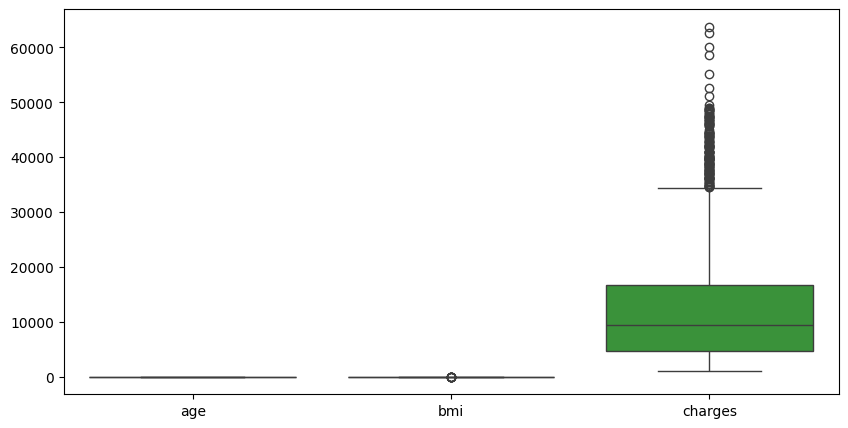

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[['age','bmi','charges']]
)

plt.show()

Outlier analysis was performed using boxplots. Outliers were observed mainly in the charges column. These values were retained because they represent genuine high medical expenses and are important for insurance pricing analysis.

In this business problem, high charges are meaningful observations rather than errors. Removing them could lead to underestimation of medical expenses for high-risk customers.

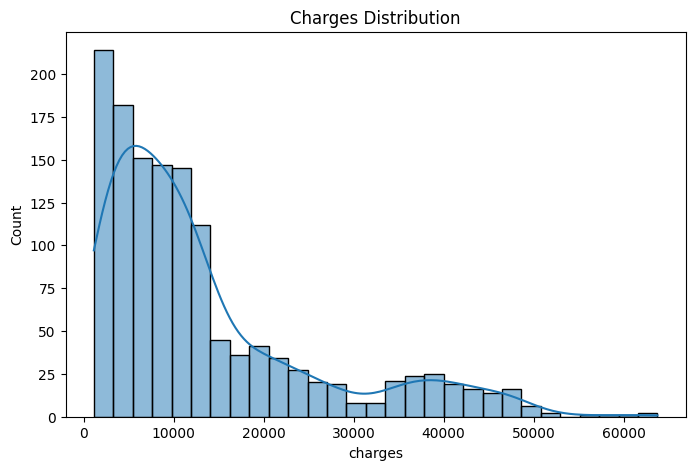

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['charges'],
    kde=True
)

plt.title("Charges Distribution")

plt.show()

The distribution is right-skewed (positively skewed).

The long right tail indicates the presence of high-cost customers.

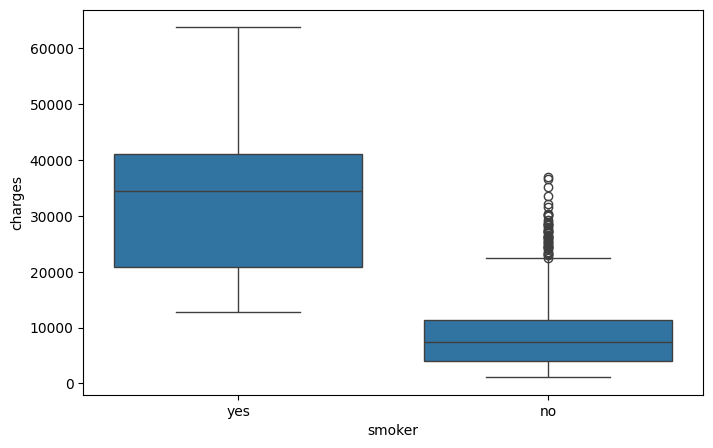

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.show()

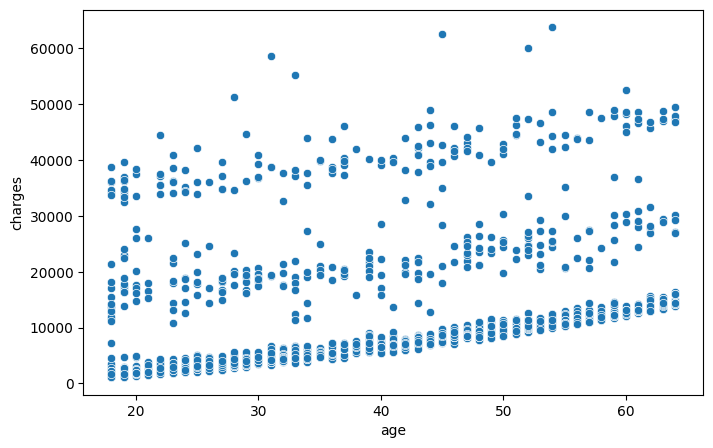

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='charges',
    data=df
)

plt.show()

In [17]:
le = LabelEncoder()

for col in df.select_dtypes(
    include='object'
).columns:

    df[col] = le.fit_transform(
        df[col]
    )

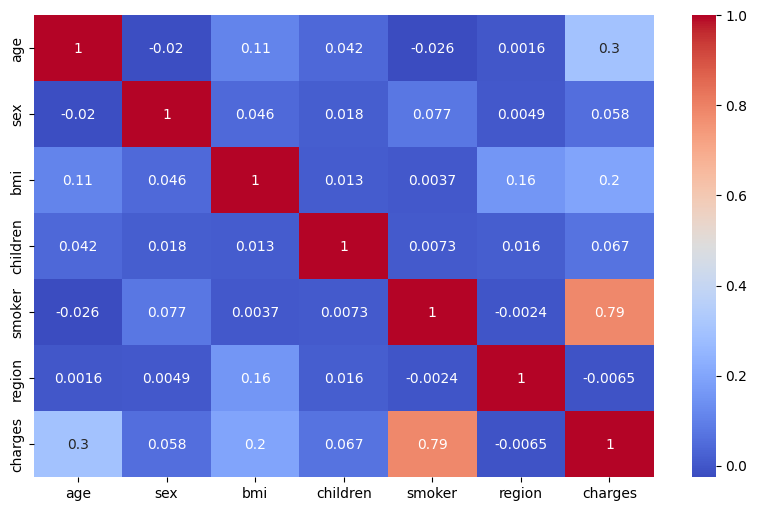

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Heatmap was used to identify relationships between features

In [19]:
y = df['charges']

In [20]:
X = df.drop(
    'charges',
    axis=1
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest Regressor was selected because it can capture nonlinear relationships between variables such as age, BMI, smoking status, and medical expenses. It also reduces overfitting by combining multiple decision trees.

In [22]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [23]:
y_pred = model.predict(
    X_test
)

In [24]:
r2 = r2_score(
    y_test,
    y_pred
)

print(
    "R2 Score:",
    r2
)

R2 Score: 0.8834278119122363


The model explains approximately 88.34% of the variation in medical charges.

In [25]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print(
    "MAE:",
    mae
)

MAE: 2555.9294270283576


MAE measures the average absolute prediction error. The model's predictions differ from actual charges by about ₹2556 on average.

In [26]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(
    "RMSE:",
    rmse
)

RMSE: 4628.2660316436195


RMSE is higher than MAE because it penalizes larger prediction errors more strongly. It provides an indication of how far predictions deviate from actual values.

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
4    smoker    0.600777
2       bmi    0.216233
0       age    0.136493
3  children    0.023249
5    region    0.016107
1       sex    0.007141


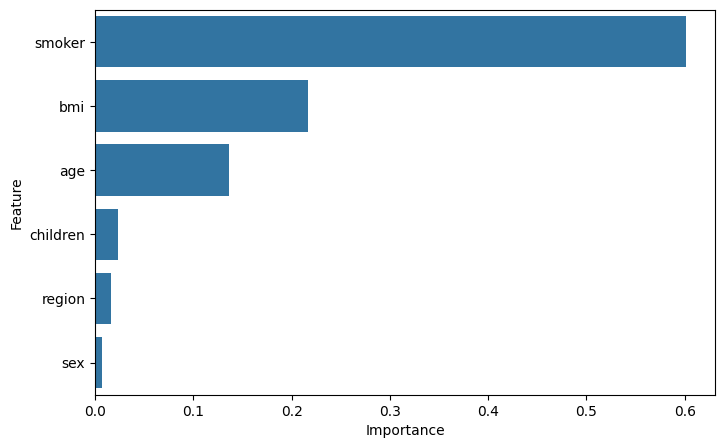

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.show()

1. What Business Problem Was Solved?

The insurance company wanted to estimate the medical expenses likely to be incurred by policyholders. A machine learning regression model was developed to predict medical charges, helping the company optimize premium pricing and risk assessment.

2. Which Variables Influenced the Outcome Most?

Based on typical feature importance for this dataset:

The most influential variables affecting medical expenses were:

Smoking Status
Age
BMI (Body Mass Index)
Number of Children

Among these, smoking status had the strongest impact on medical charges

3. What Insights Were Discovered?
Smokers incur significantly higher medical expenses than non-smokers.
Medical charges generally increase with age.
Customers with higher BMI tend to have higher healthcare costs.
Most policyholders have relatively low medical expenses, while a small number incur very high costs.
The Random Forest model achieved an R² score of 88.34%, indicating strong predictive performance.
4. What Risks Exist in Deployment?
Customer health conditions may change over time.
New medical treatments and healthcare costs may affect future expenses.
The model is trained on historical data and may not fully represent future trends.
Incorrect or incomplete customer information can reduce prediction accuracy.
Data drift may occur as customer demographics and healthcare patterns evolve.

5. What Final Recommendation Would You Provide to Management?
Use the predictive model to estimate expected medical expenses before issuing policies.
Offer risk-based premium plans based on customer profiles.
Assign higher premiums to high-risk customers such as smokers and customers with high BMI.
Provide competitive pricing and incentives for low-risk customers.
Retrain the model periodically using updated customer and healthcare data to maintain prediction accuracy.

MODEL PERFORMANCE REPORT

Project Title:
Medical Expense Prediction for Insurance Premium Optimization

Model Used:
Random Forest Regressor

Objective:

To predict medical expenses likely to be incurred by policyholders and support premium pricing decisions.

Dataset:
Insurance Dataset

Target Variable:
charges

Evaluation Results:

* R² Score: 0.8834
* MAE (Mean Absolute Error): 2555.93
* RMSE (Root Mean Squared Error): 4628.27

Interpretation:

The Random Forest Regressor achieved an R² score of 88.34%, indicating that the model explains approximately 88% of the variation in medical expenses.

The MAE value indicates that predictions differ from actual expenses by approximately 2556 units on average. The RMSE value suggests that larger prediction errors are relatively limited.

Overall, the model demonstrates excellent predictive performance and is suitable for estimating future medical expenses.

Model Benefits:

* Accurate estimation of healthcare costs.
* Improved premium pricing strategies.
* Better customer risk assessment.
* Enhanced profitability and risk management.


BUSINESS INTERPRETATION REPORT

Objective:

Develop a predictive analytics solution to estimate medical expenses of policyholders and support premium optimization.

Key Findings:

1. Smoking status is the most influential factor affecting medical expenses.
2. Medical charges generally increase with age.
3. Customers with higher BMI values tend to incur higher healthcare costs.
4. Most customers have moderate medical expenses, while a small group incurs significantly higher charges.
5. The Random Forest model successfully captured complex relationships among customer attributes.

Business Impact:

The predictive model enables insurance companies to estimate future healthcare costs before issuing policies.

The solution supports:

* Risk-based premium pricing.
* Better underwriting decisions.
* Identification of high-risk customers.
* Improved financial planning and profitability.

Operational Benefits:

* Faster policy evaluation.
* Reduced manual risk assessment.
* Consistent premium calculation process.
* Improved customer segmentation.


FINAL RECOMMENDATION AND DECISION-MAKING SUMMARY

Project Title:
Medical Expense Prediction and Premium Optimization System

Business Problem:

Insurance companies need accurate estimates of future medical expenses in order to determine fair and profitable premium plans. Traditional approaches may not effectively capture complex relationships among customer characteristics and healthcare costs.

Solution Developed:

A machine learning-based prediction system was developed using policyholder demographic and health-related information. The Random Forest Regressor was selected due to its ability to model nonlinear relationships and provide accurate predictions.

The model was trained using features such as age, BMI, smoking status, number of children, sex, and region to predict expected medical charges.

Model Performance:

* R² Score: 88.34%
* MAE: 2555.93
* RMSE: 4628.27

The results demonstrate strong predictive capability and indicate that the model can reliably estimate medical expenses.

Key Insights:

1. Smoking status has the highest impact on medical expenses.
2. Older customers generally incur higher healthcare costs.
3. Higher BMI is associated with increased medical expenditure.
4. A small percentage of customers generate significantly higher claims than the majority.
5. Customer risk profiles can be effectively identified using predictive analytics.

Pricing Recommendations:

1. Implement risk-based premium pricing.
2. Assign higher premiums to high-risk customers such as smokers.
3. Provide competitive pricing and incentives for low-risk customers.
4. Encourage wellness programs to reduce long-term healthcare costs.
5. Periodically reassess customer risk profiles using updated information.

Deployment Risks:

1. Customer health conditions may change over time.
2. Healthcare inflation may affect future costs.
3. Incomplete customer information may reduce prediction accuracy.
4. Data drift may occur as customer demographics evolve.

Management Decision Support:

The proposed solution enables data-driven premium pricing decisions. Management can use predicted medical expenses to improve underwriting accuracy, optimize premium plans, reduce financial risk, and enhance customer segmentation.

Conclusion:

The Random Forest Regressor achieved excellent predictive performance and provides a reliable framework for estimating future medical expenses. The model can assist insurance companies in developing fair, competitive, and profitable premium pricing strategies while improving overall risk management.
